# Colony: 10 ants, one shared PPO brain
Every ant uses the **same** network. Each ant's experience is one training sample.

In [1]:
import sys, os
sys.path.append(os.path.abspath("../src"))

import torch
import torch.nn as nn
from torch.distributions import Categorical
from IPython.display import clear_output, Image
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt

from colony_env import ColonyEnv
from ppo import ActorCriticNet, RolloutBuffer, ppo_update

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

/home/sabrina/.local/lib/python3.10/site-packages/torch/cuda/__init__.py:174: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


In [2]:
# ---- environment ----
n_ants = 10          # ants per colony
max_steps = 500      # steps per episode

def make_env():
    return ColonyEnv(n_ants=n_ants, max_steps=max_steps)

env = make_env()
state_dim = env.observation_space.shape[0]   # observation of ONE ant
action_dim = env.action_space.n
obs, _ = env.reset()
print("state_dim:", state_dim, "| action_dim:", action_dim, "| obs shape for all ants:", obs.shape)

state_dim: 130 | action_dim: 5 | obs shape for all ants: (10, 130)


In [3]:
# ---- training settings ----
seed = 0
n_envs = 4                  # colonies running in parallel
n_steps = 512              # env steps per rollout
total_timesteps = 2_000_000   # counted in ant-actions (1 env step = n_ants actions)

n_agents = n_envs * n_ants  # 40 ants collect data at the same time

gamma = 0.99
gae_lambda = 0.95
clip_eps = 0.2
lr = 3e-4
update_epochs = 4
mini_batch_size = 1024
entropy_coef = 0.001
critic_coef = 0.5
max_grad_norm = 0.5

In [4]:
def init_rollout_state(envs, seed=0):
    obs = np.stack([env.reset(seed=seed + i)[0] for i, env in enumerate(envs)])   # (n_envs, n_ants, state_dim)
    return {"obs": obs, "ep_return": np.zeros(len(envs))}


def collect_rollout(envs, agent, buffer, state):
    buffer.reset()
    n_envs = len(envs)
    episode_stats = []

    for _ in range(buffer.n_steps):
        obs = state["obs"]                                            # (n_envs, n_ants, state_dim)
        state_t = torch.as_tensor(obs.reshape(-1, state_dim), dtype=torch.float32, device=device)
        action, log_prob, value = agent.act(state_t)                  # one forward pass for all 40 ants
        actions_np = action.cpu().numpy().reshape(n_envs, n_ants)

        next_obs = np.empty_like(obs)
        rewards = np.zeros((n_envs, n_ants), dtype=np.float32)
        dones = np.zeros((n_envs, n_ants), dtype=np.float32)

        for i, env in enumerate(envs):
            o, r, terminated, truncated, info = env.step(actions_np[i])
            state["ep_return"][i] += r.mean()                         # average return per ant

            if truncated:                                             # episode over -> log it and restart
                episode_stats.append({
                    "return": float(state["ep_return"][i]),
                    "delivered": info["total_delivered"],
                    "collected": info["total_collected"],
                    "eaten": info["total_eaten"],
                    "invalid": info["total_invalid"],
                    "deaths": info["total_died"],
                })
                state["ep_return"][i] = 0.0
                o, _ = env.reset()

            next_obs[i] = o
            rewards[i] = r
            dones[i] = terminated | truncated                         # per-ant done flag

        buffer.add(state_t, action, log_prob,
                   torch.as_tensor(rewards.reshape(-1), device=device),
                   torch.as_tensor(dones.reshape(-1), device=device),
                   value)
        state["obs"] = next_obs

    last_state = torch.as_tensor(state["obs"].reshape(-1, state_dim), dtype=torch.float32, device=device)
    return agent.get_value(last_state), episode_stats

In [5]:
def evaluate_policy(net=None, n_episodes=5, seed=10000):
    """Run full episodes with 10 ants. net=None -> ants move randomly (used as a baseline)."""
    env = make_env()
    results = []
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep)
        done, total = False, 0.0
        while not done:
            if net is None:
                actions = env.np_random.integers(action_dim, size=n_ants)
            else:
                obs_t = torch.as_tensor(obs, dtype=torch.float32, device=device)
                actions = net.act(obs_t)[0].cpu().numpy()
            obs, r, terminated, truncated, info = env.step(actions)
            total += r.mean()
            done = truncated
        results.append({"return": total, "delivered": info["total_delivered"], "deaths": info["total_died"]})
    return {k: float(np.mean([r[k] for r in results])) for k in results[0]}


random_baseline = evaluate_policy(None, n_episodes=10)
print("Random ants:", random_baseline)

Random ants: {'return': 18.10030048017623, 'delivered': 0.8, 'deaths': 12.6}


In [6]:
def log_point(history, key, x, y):
    h = history.setdefault(key, {"x": [], "y": []})
    h["x"].append(x)
    h["y"].append(float(y))


# (title, y-label, lines to draw, key of the random baseline or None)
PANELS = [
    ("Average return per ant",         "reward",         ["train/return", "eval/return"],       "return"),
    ("Food delivered to the colony",   "food / episode", ["train/delivered", "eval/delivered"], "delivered"),
    ("Ant deaths",                     "deaths / episode", ["train/deaths", "eval/deaths"],     "deaths"),
    ("Food collected vs eaten",        "food / episode", ["train/collected", "train/eaten"],    None),
    ("Blocked / invalid moves",        "moves / episode", ["train/invalid"],                    None),
    ("Policy entropy (randomness)",    "entropy",        ["algo/entropy"],                      None),
]

def live_plot(history, smooth_k=5):
    clear_output(wait=True)
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    for ax, (title, ylabel, keys, base) in zip(axes.ravel(), PANELS):
        for key in keys:
            if key not in history:
                continue
            x, y = np.array(history[key]["x"]), np.array(history[key]["y"])
            label = key.split("/")[1] + (" (test)" if key.startswith("eval/") else "")
            if key.startswith("eval/"):
                ax.plot(x, y, "o-", color="black", label=label)
            else:
                (line,) = ax.plot(x, y, alpha=0.25)
                if len(y) >= smooth_k:
                    ys = np.convolve(y, np.ones(smooth_k) / smooth_k, mode="valid")
                    ax.plot(x[smooth_k - 1:], ys, color=line.get_color(), lw=2, label=label)
                else:
                    line.set_alpha(1); line.set_label(label)
        if base:
            ax.axhline(random_baseline[base], color="gray", ls="--", label="random ants")
        ax.set_title(title, fontweight="bold")
        ax.set_xlabel("training steps (ant-actions)")
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)
        if ax.get_legend_handles_labels()[0]:
            ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()

In [7]:
def train(plot_every=5, eval_every=10):
    envs = [make_env() for _ in range(n_envs)]
    net = ActorCriticNet().to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    buffer = RolloutBuffer(n_steps, n_agents, state_dim, gamma, gae_lambda)
    state = init_rollout_state(envs, seed=seed)

    steps_per_update = n_steps * n_agents
    n_updates = total_timesteps // steps_per_update
    global_step, best_eval = 0, -float("inf")
    history = {}

    for upd in range(1, n_updates + 1):
        last_value, ep_stats = collect_rollout(envs, net, buffer, state)
        buffer.compute_gae(last_value)
        metrics = ppo_update(net, buffer, optimizer)
        global_step += steps_per_update

        log_point(history, "algo/entropy", global_step, metrics["entropy"])
        if ep_stats:
            for key in ["return", "delivered", "collected", "eaten", "invalid", "deaths"]:
                log_point(history, f"train/{key}", global_step, np.mean([s[key] for s in ep_stats]))

        if upd % eval_every == 0 or upd == n_updates:
            ev = evaluate_policy(net)
            for key in ["return", "delivered", "deaths"]:
                log_point(history, f"eval/{key}", global_step, ev[key])
            if ev["return"] > best_eval:
                best_eval = ev["return"]
                torch.save(net.state_dict(), "colony_ppo_best.pt")

        if upd % plot_every == 0 or upd == n_updates:
            live_plot(history)
            print(f"Update {upd}/{n_updates} | steps {global_step}")

    torch.save(net.state_dict(), "colony_ppo.pt")
    return net, history

## Train

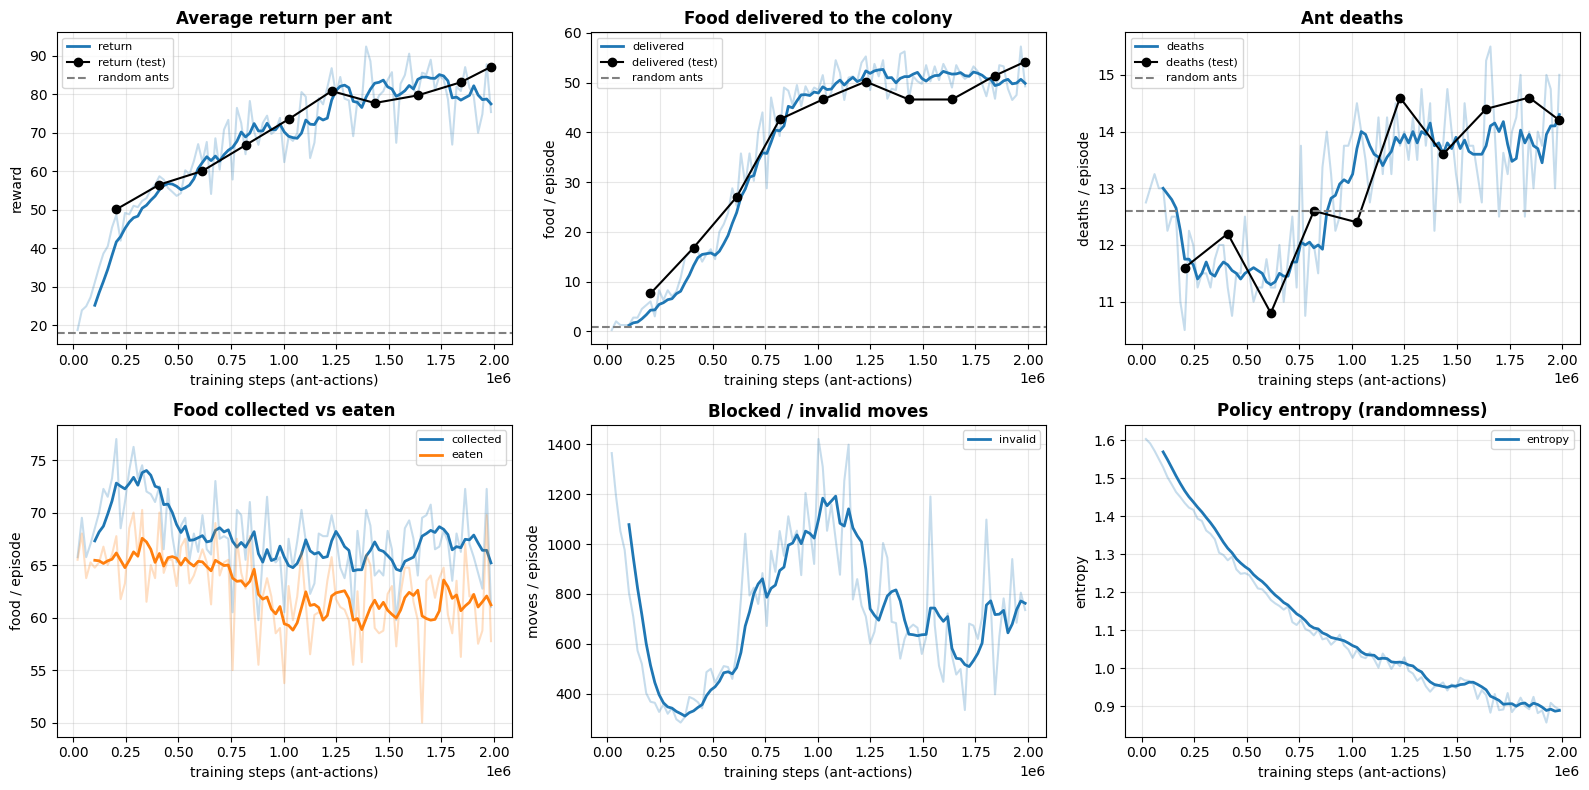

Update 97/97 | steps 1986560


In [8]:
net, history = train()

## How to read the graphs
- **Dashed gray line** = what ants achieve by moving randomly. Learning means beating it.
- **Average return per ant**: total reward of one ant per episode. Should go up.
- **Food delivered**: food brought back to the colony per episode. This is the real goal. Should go up.
- **Ant deaths**: ants that starved per episode. Should go down.
- **Food collected vs eaten**: collected is picked up; eaten is consumed. Delivered is shown separately.
- **Blocked / invalid moves**: walking into trees, walls, other ants, or eating with nothing. Should go down.
- **Policy entropy**: how random the ants' decisions are. Starts near 1.6 (fully random) and slowly falls as they learn.
- **Colored lines** are training (smoothed, faint = raw). **Black dots** are test runs of the current policy on fixed seeds.

In [ ]:
print(lll)

<class 'numpy.ndarray'> (800, 800, 3) uint8
GIF saved to: /home/sabrina/Documents/ant-colony-ppo/notebooks/colony.gif


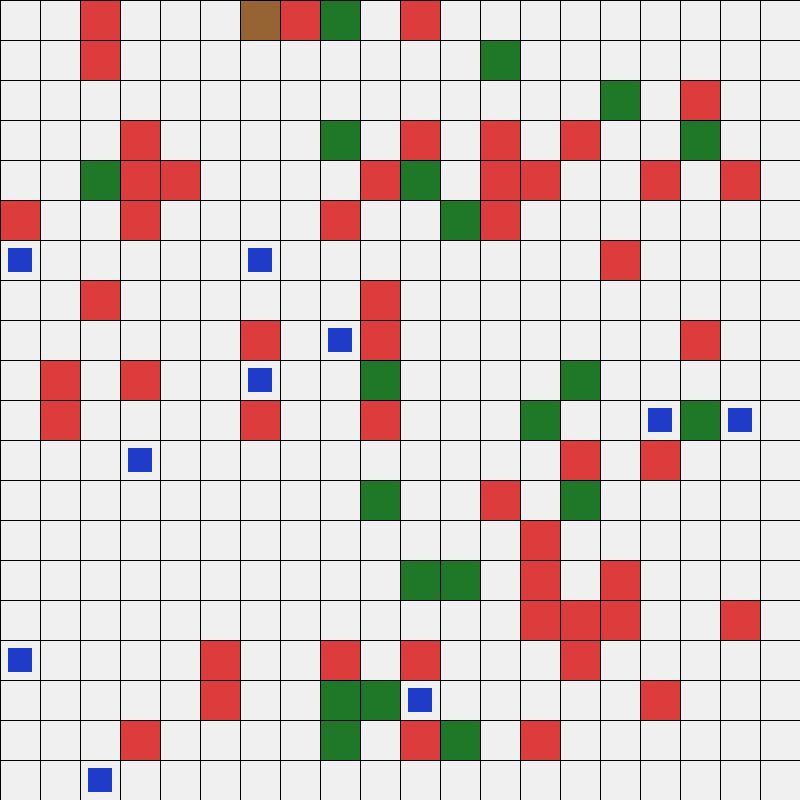

In [9]:
import imageio.v2 as imageio


def record_colony_gif(net, filename="colony.gif", steps=300, seed=123, fps=10):
    env = ColonyEnv(n_ants=n_ants, max_steps=steps, render_mode="rgb_array")
    obs, info = env.reset(seed=seed)

    frames = [env.render()]          # first frame, before any step

    for _ in range(steps):
        obs_t = torch.as_tensor(obs, dtype=torch.float32, device=device)
        with torch.no_grad():
            actions = net.act(obs_t)[0].cpu().numpy()

        obs, rewards, terminated, truncated, info = env.step(actions)
        frames.append(env.render())

        if truncated:                # don't stop when a single ant dies
            break

    env.close()

    imageio.mimsave(filename, frames, fps=fps, loop=0)
    print("GIF saved to:", os.path.abspath(filename))
    return filename


# Sanity check: must print an ndarray of shape (800, 800, 3)
test_env = ColonyEnv(n_ants=n_ants, max_steps=10, render_mode="rgb_array")
test_env.reset(seed=123)
f = test_env.render()
print(type(f), f.shape, f.dtype)

path = record_colony_gif(net, "colony.gif", steps=300, seed=123, fps=10)
Image(filename=path)

In [10]:
import time
from IPython.display import clear_output

def watch_colony(net, steps=300, delay=0.5, seed=123):
    env = ColonyEnv(n_ants=n_ants, max_steps=steps, render_mode="rgb_array")
    obs, info = env.reset(seed=seed)
    done = False

    while not done:
        obs_t = torch.as_tensor(obs, dtype=torch.float32, device=device)
        actions = net.act(obs_t)[0].cpu().numpy()
        obs, rewards, terminated, truncated, info = env.step(actions)
        done = truncated

        clear_output(wait=True)
        print(env.render())
        print(f"step {info['step']}/{steps} | colony food: {info['colony_food']} | "
              f"delivered: {info['total_delivered']} | deaths: {info['total_died']}")
        time.sleep(delay)

watch_colony(net)

[[[  0   0   0]
  [  0   0   0]
  [  0   0   0]
  ...
  [  0   0   0]
  [  0   0   0]
  [  0   0   0]]

 [[  0   0   0]
  [240 240 240]
  [240 240 240]
  ...
  [240 240 240]
  [240 240 240]
  [240 240 240]]

 [[  0   0   0]
  [240 240 240]
  [240 240 240]
  ...
  [240 240 240]
  [240 240 240]
  [240 240 240]]

 ...

 [[  0   0   0]
  [240 240 240]
  [240 240 240]
  ...
  [240 240 240]
  [240 240 240]
  [240 240 240]]

 [[  0   0   0]
  [240 240 240]
  [240 240 240]
  ...
  [240 240 240]
  [240 240 240]
  [240 240 240]]

 [[  0   0   0]
  [240 240 240]
  [240 240 240]
  ...
  [240 240 240]
  [240 240 240]
  [240 240 240]]]
step 116/300 | colony food: 0 | delivered: 30 | deaths: 0


KeyboardInterrupt: 

In [ ]:
# Load best checkpoint and evaluate
net = ActorCriticNet().to(device)
net.load_state_dict(torch.load("../checkpoints/colony_ppo_best.pt", map_location=device))
net.eval()

ev = evaluate_policy(net, n_episodes=10)
print("Trained policy:", ev)

random_baseline = evaluate_policy(None, n_episodes=10)
print("Random ants:    ", random_baseline)

Trained policy: {'return': 39.673221010899866, 'delivered': 52.0, 'deaths': 14.4}
Random ants:     {'return': 18.10030048017623, 'delivered': 0.8, 'deaths': 12.6}
